<a href="https://colab.research.google.com/github/aj11anuj/optimly/blob/main/work/notebooks/w03_data_contract.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-04 — Search Intelligence Data Contract

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Unit of analysis + time window

*One row = one what, over which dates? State it, then verify it below.*

One row represents one content item for one client on one date, identified by client_hash_id, content_hash_id, and report_date. The feature window is March 1 - 31, 2026.

## 2. Fields: feature / label / context / excluded

*Sort every field you plan to touch into these four buckets. Excluded needs a why.*

Field: gsc_impressions, gsc_clicks, gsc_avg_position, ga4_sessions, ga4_engaged_sessions

Label: April performance decline, using March-to-April GSC clicks as a proxy for identifying content that may need refreshing.

Context: client_hash_id, content_hash_id, report_date, gsc_data_available, ga4_data_available

Excluded: April metrics as features because they occur after the March decision point, client names, URLs, and private queries, to protect privacy

## 3. Verify it with queries (grain, counts, missing values, windows)

*Every claim above gets a query cell here. A contract claim without a query next to it is a guess.*

Grain: March check found 0 duplicate key groups, 0 excess rows, and a maximum of 1 row per (client_hash_id, content_hash_id, report_date).

Counts and window: March contained 9,841,378 rows, 331,437 unique content items, and 55 clients, covering March 1 – 31, 2026.

Missing values / availability: GSC was available for 3,611,061 of 9,841,378 checked rows (36.69%). GA4 was available for 413,966 of 6,822,637 checked rows (6.07%).

# Verify the grains
```
SELECT
    COUNT(*) AS duplicate_groups,
    SUM(row_count - 1) AS excess_rows,
    MAX(row_count) AS max_rows_per_key
FROM (
    SELECT
        client_hash_id,
        content_hash_id,
        report_date,
        COUNT(*) AS row_count
    FROM fact_content_daily_performance
    WHERE report_date BETWEEN '2026-03-01' AND '2026-03-31'
    GROUP BY client_hash_id, content_hash_id, report_date
    HAVING COUNT(*) > 1
) duplicates;
```
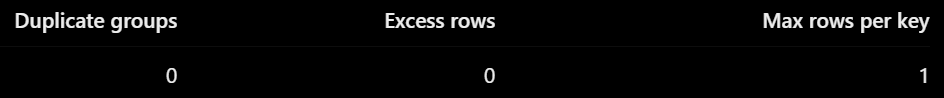

# March Slice
```
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT content_hash_id) AS unique_content,
    COUNT(DISTINCT client_hash_id) AS unique_clients,
    MIN(report_date) AS start_date,
    MAX(report_date) AS end_date
FROM fact_content_daily_performance
WHERE report_date BETWEEN '2026-03-01' AND '2026-03-31';
```

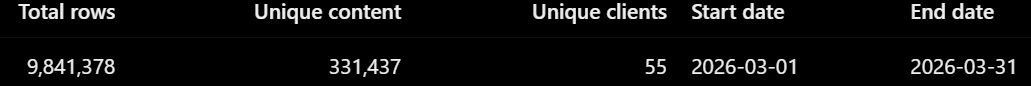

# Metrics
```
SELECT
    COUNT(*) AS total_rows,
    COUNT(*) FILTER (
        WHERE gsc_data_available IS TRUE
    ) AS gsc_available_rows,
    ROUND(
        100.0 * COUNT(*) FILTER (
            WHERE gsc_data_available IS TRUE
        ) / COUNT(*), 2
    ) AS gsc_availability_pct,
    COUNT(*) FILTER (
        WHERE ga4_data_available IS TRUE
    ) AS ga4_available_rows,
    ROUND(
        100.0 * COUNT(*) FILTER (
            WHERE ga4_data_available IS TRUE
        ) / COUNT(*), 2
    ) AS ga4_availability_pct
FROM fact_content_daily_performance
WHERE report_date BETWEEN '2026-03-01' AND '2026-03-31';
```
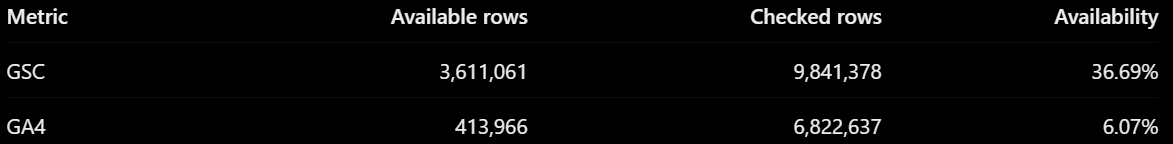


## 4. Data limits

*What can this data never tell you? Unbalanced history, GSC-only early rows, window overlaps.*

The data measures observed performance, not content quality or the actual need to refresh a page. GSC and GA4 coverage is uneven, so missing metrics do not necessarily mean zero performance. A single month may not capture seasonality or longer-term trends. The March to April comparison is a short term proxy and cannot establish that a content update caused a performance change. Historical coverage may also be unbalanced, and overlapping observation and outcome windows could introduce leakage if not separated carefully.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` then submit your repo URL on the card. Done.